# Ensemble Model — Random Forest + XGBoost

## Chiến lược kết hợp

Dùng **Stacking** — cách kết hợp mạnh nhất:
- **Layer 1 (Base models):** Random Forest + XGBoost train độc lập, mỗi model output xác suất cho 11 class
- **Layer 2 (Meta-model):** Logistic Regression học cách kết hợp output của 2 model trên để ra dự đoán cuối

So với Voting đơn thuần (trung bình xác suất), Stacking cho phép meta-model **tự học trọng số** — tức là biết khi nào nên tin RF hơn, khi nào nên tin XGBoost hơn tùy từng class.

| Bước | Mô tả |
|------|-------|
| 1 | Load data, chuẩn bị X/y |
| 2 | Train RF và XGBoost riêng lẻ trên train set |
| 3 | Tạo meta-features bằng cross-val predictions |
| 4 | Train meta-model (Logistic Regression) |
| 5 | Đánh giá ensemble trên validation |
| 6 | Gộp train+val, train final ensemble |
| 7 | Predict test, xuất submission |


In [19]:
print('Đang khai báo thư viện')

import pandas as pd
import numpy as np
import os
import warnings
import joblib
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (classification_report, accuracy_score,
                             f1_score, confusion_matrix)
from sklearn.model_selection import cross_val_predict
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

print('Khai báo thư viện thành công')


Đang khai báo thư viện
Khai báo thư viện thành công


In [20]:
print('Khai báo dữ liệu')

train_path = os.path.join("..", "Data", "DataCleaned", "data_train_cleaned.csv")
val_path   = os.path.join("..", "Data", "DataCleaned", "validation_cleaned.csv")
test_path  = os.path.join("..", "Data", "DataCleaned", "test_cleaned.csv")

df_train = pd.read_csv(train_path)
df_val   = pd.read_csv(val_path)
df_test  = pd.read_csv(test_path)

print(f"Train shape     : {df_train.shape}")
print(f"Validation shape: {df_val.shape}")
print(f"Test shape      : {df_test.shape}")

# Drop các cột không cần thiết
drop_cols = ['Id', 'Artist Name', 'Track Name', 'key']

def prep(df, has_label=True):
    drop = [c for c in drop_cols if c in df.columns]
    if has_label:
        X = df.drop(columns=['Class'] + drop)
        y = df['Class']
        return X, y
    else:
        X = df.drop(columns=drop)
        return X

X_train, y_train = prep(df_train)
X_val,   y_val   = prep(df_val)
X_test           = prep(df_test, has_label=False)

# Align test columns theo train
X_test = X_test[X_train.columns]

print(f"\nX_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")
print(f"Features: {X_train.columns.tolist()}")


Khai báo dữ liệu
Train shape     : (11516, 20)
Validation shape: (2880, 17)
Test shape      : (3600, 16)

X_train : (11516, 15)
X_val   : (2880, 15)
X_test  : (3600, 15)
Features: ['Popularity', 'danceability', 'energy', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'time_signature', 'key_sin', 'key_cos']


In [21]:
# Random Forest
rf_base = RandomForestClassifier(
    n_estimators     = 300,
    max_depth        = 15,
    min_samples_leaf = 5,
    max_features     = 'sqrt',
    class_weight     = 'balanced',
    random_state     = 42,
    n_jobs           = -1
)

# XGBoost
xgb_base = XGBClassifier(
    n_estimators     = 400,
    max_depth        = 8,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    reg_alpha        = 0.1,
    reg_lambda       = 0.1,
    min_child_weight = 3,
    eval_metric      = 'mlogloss',
    random_state     = 42,
    n_jobs           = -1,
    verbosity        = 0
)

print("Đã định nghĩa RF và XGBoost base models")
print(f"   RF  : n_estimators={rf_base.n_estimators}, max_depth={rf_base.max_depth}")
print(f"   XGB : n_estimators={xgb_base.n_estimators}, max_depth={xgb_base.max_depth}")


Đã định nghĩa RF và XGBoost base models
   RF  : n_estimators=300, max_depth=15
   XGB : n_estimators=400, max_depth=8


In [22]:
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# Train RF
print("Training Random Forest...")
rf_base.fit(X_train, y_train)
rf_val_acc = accuracy_score(y_val, rf_base.predict(X_val))
rf_val_f1  = f1_score(y_val, rf_base.predict(X_val), average='macro', zero_division=0)
print(f"  RF done  | Val Accuracy={rf_val_acc:.4f} | Val Macro F1={rf_val_f1:.4f}")

# Train XGBoost (với early stopping trên val)
print("\nTraining XGBoost...")
xgb_es = XGBClassifier(
    n_estimators          = 1000,
    max_depth             = 8,
    learning_rate         = 0.05,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    reg_alpha             = 0.1,
    reg_lambda            = 0.1,
    min_child_weight      = 3,
    early_stopping_rounds = 50,
    eval_metric           = 'mlogloss',
    random_state          = 42,
    n_jobs                = -1,
    verbosity             = 0
)
xgb_es.fit(
    X_train, y_train,
    sample_weight = sample_weights,
    eval_set      = [(X_val, y_val)],
    verbose       = False
)
best_iter = xgb_es.best_iteration
print(f"  Best iteration: {best_iter}")

# Train lại XGBoost với n_estimators cố định (không early stopping)
xgb_base.set_params(n_estimators=best_iter)
xgb_base.fit(X_train, y_train, sample_weight=sample_weights)
xgb_val_acc = accuracy_score(y_val, xgb_base.predict(X_val))
xgb_val_f1  = f1_score(y_val, xgb_base.predict(X_val), average='macro', zero_division=0)
print(f"  XGB done | Val Accuracy={xgb_val_acc:.4f} | Val Macro F1={xgb_val_f1:.4f}")

print(f"\n{'Model':10s} | {'Val Acc':>10s} | {'Val Macro F1':>12s}")
print("-" * 38)
print(f"{'RF':10s} | {rf_val_acc:>10.4f} | {rf_val_f1:>12.4f}")
print(f"{'XGBoost':10s} | {xgb_val_acc:>10.4f} | {xgb_val_f1:>12.4f}")


Training Random Forest...
  RF done  | Val Accuracy=0.4281 | Val Macro F1=0.4340

Training XGBoost...
  Best iteration: 214
  XGB done | Val Accuracy=0.4441 | Val Macro F1=0.4598

Model      |    Val Acc | Val Macro F1
--------------------------------------
RF         |     0.4281 |       0.4340
XGBoost    |     0.4441 |       0.4598


## Stacking Ensemble

### Cách hoạt động
1. Dùng **5-fold cross-validation** trên train set để sinh ra **meta-features** (xác suất của RF và XGBoost) mà không bị data leakage
2. Meta-model (Logistic Regression) học từ 22 features này (11 class × 2 models) để ra dự đoán cuối


In [24]:
print("Building Stacking Ensemble...")
print("(Quá trình này mất ~3-5 phút do cross-validation)")

estimators = [
    ('rf',  rf_base),
    ('xgb', xgb_base)
]

stack = StackingClassifier(
    estimators      = estimators,
    final_estimator = LogisticRegression(
                          max_iter     = 1000,
                          C            = 1.0,
                          class_weight = 'balanced',
                          random_state = 42,
                          n_jobs       = -1
                      ),
    cv          = 5,
    stack_method= 'predict_proba',  # dùng xác suất thay vì class label
    passthrough = False,            # chỉ dùng output của base models
    n_jobs      = -1
)

stack.fit(X_train, y_train)
print("Stacking ensemble trained!")


Building Stacking Ensemble...
(Quá trình này mất ~3-5 phút do cross-validation)
Stacking ensemble trained!


## Đánh giá trên Validation

In [25]:
# Predict từ cả 3 model
y_pred_rf    = rf_base.predict(X_val)
y_pred_xgb   = xgb_base.predict(X_val)
y_pred_stack = stack.predict(X_val)

# Accuracy & F1
results = {
    'Random Forest' : (y_pred_rf,    '#3498db'),
    'XGBoost'       : (y_pred_xgb,   '#2ecc71'),
    'Stacking (RF+XGB)': (y_pred_stack, '#e74c3c')
}

print("=" * 60)
print(f"{'Model':22s} | {'Accuracy':>10s} | {'Macro F1':>10s}")
print("-" * 60)
for name, (y_pred, _) in results.items():
    acc = accuracy_score(y_val, y_pred)
    f1  = f1_score(y_val, y_pred, average='macro', zero_division=0)
    print(f"{name:22s} | {acc:>10.4f} | {f1:>10.4f}")
print("=" * 60)

# Classification report cho ensemble
print("\n=== CLASSIFICATION REPORT — STACKING (Validation) ===")
print(classification_report(y_val, y_pred_stack, zero_division=0))


Model                  |   Accuracy |   Macro F1
------------------------------------------------------------
Random Forest          |     0.4281 |     0.4340
XGBoost                |     0.4441 |     0.4598
Stacking (RF+XGB)      |     0.4292 |     0.4535

=== CLASSIFICATION REPORT — STACKING (Validation) ===
              precision    recall  f1-score   support

           0       0.20      0.49      0.29       100
           1       0.21      0.22      0.22       220
           2       0.32      0.46      0.38       204
           3       0.46      0.69      0.55        64
           4       0.21      0.71      0.33        62
           5       0.71      0.74      0.73       231
           6       0.38      0.23      0.29       414
           7       0.72      0.89      0.80        92
           8       0.49      0.73      0.59       297
           9       0.52      0.46      0.49       404
          10       0.51      0.26      0.34       792

    accuracy                          

## So sánh F1 per class: RF vs XGBoost vs Stacking

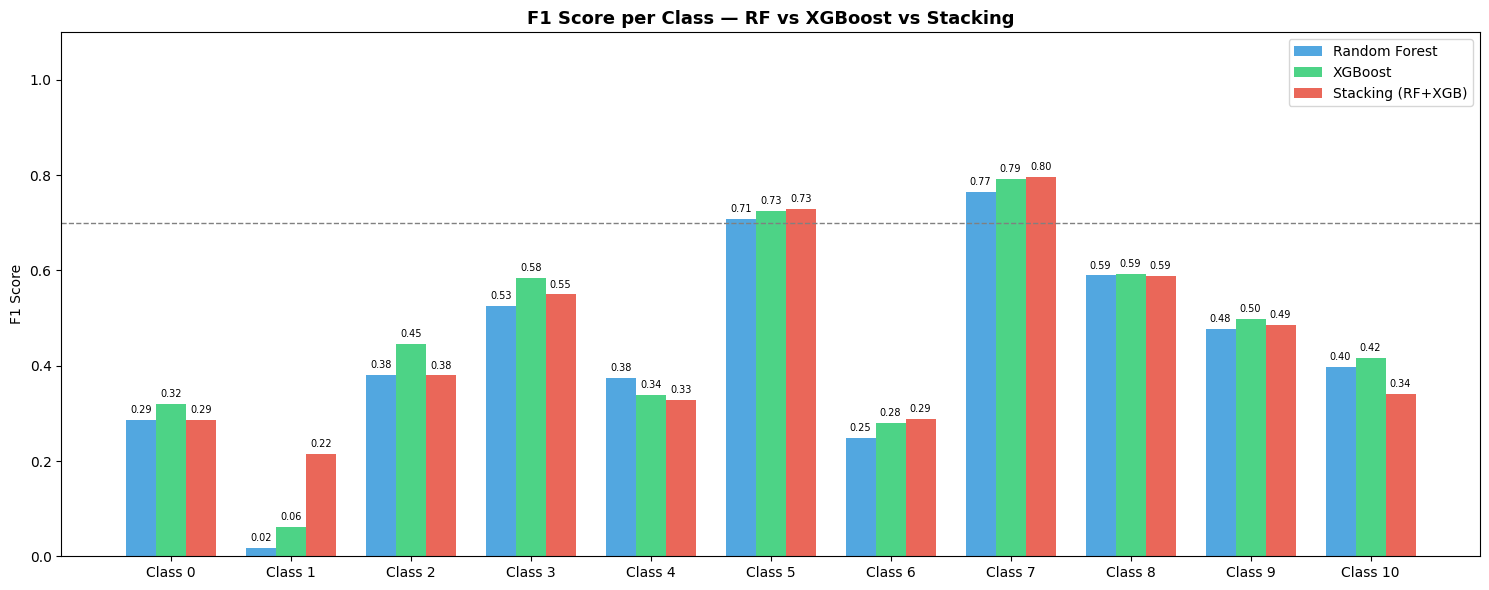

Per-class F1 — Stacking vs tốt nhất trong RF/XGB:
  Class |     RF |    XGB |  Stack |       Winner
--------------------------------------------------
      0 |  0.287 |  0.321 |  0.287 |        Base 
      1 |  0.018 |  0.061 |  0.215 |       Stack 
      2 |  0.381 |  0.446 |  0.380 |        Base 
      3 |  0.526 |  0.585 |  0.550 |        Base 
      4 |  0.375 |  0.339 |  0.328 |        Base 
      5 |  0.708 |  0.726 |  0.729 |       Stack 
      6 |  0.249 |  0.280 |  0.289 |       Stack 
      7 |  0.766 |  0.792 |  0.796 |       Stack 
      8 |  0.590 |  0.593 |  0.588 |        Base 
      9 |  0.478 |  0.499 |  0.486 |        Base 
     10 |  0.397 |  0.416 |  0.341 |        Base 


In [26]:
classes = sorted(y_train.unique())
f1_rf    = f1_score(y_val, y_pred_rf,    average=None, labels=classes, zero_division=0)
f1_xgb   = f1_score(y_val, y_pred_xgb,  average=None, labels=classes, zero_division=0)
f1_stack = f1_score(y_val, y_pred_stack, average=None, labels=classes, zero_division=0)

x     = np.arange(len(classes))
width = 0.25

fig, ax = plt.subplots(figsize=(15, 6))
ax.bar(x - width,  f1_rf,    width, label='Random Forest',     color='#3498db', alpha=0.85)
ax.bar(x,          f1_xgb,   width, label='XGBoost',           color='#2ecc71', alpha=0.85)
ax.bar(x + width,  f1_stack, width, label='Stacking (RF+XGB)', color='#e74c3c', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([f'Class {c}' for c in classes])
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.1)
ax.set_title('F1 Score per Class — RF vs XGBoost vs Stacking', fontweight='bold', fontsize=13)
ax.legend()
ax.axhline(0.7, color='gray', linestyle='--', linewidth=1)

for bars, f1s in zip([x-width, x, x+width], [f1_rf, f1_xgb, f1_stack]):
    for xi, f1 in zip(bars, f1s):
        ax.text(xi, f1 + 0.01, f'{f1:.2f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()

print("Per-class F1 — Stacking vs tốt nhất trong RF/XGB:")
print(f"{'Class':>7s} | {'RF':>6s} | {'XGB':>6s} | {'Stack':>6s} | {'Winner':>12s}")
print("-" * 50)
for c, f_rf, f_xgb, f_st in zip(classes, f1_rf, f1_xgb, f1_stack):
    best_base = max(f_rf, f_xgb)
    winner = 'Stack ' if f_st >= best_base else 'Base '
    print(f"{c:>7d} | {f_rf:>6.3f} | {f_xgb:>6.3f} | {f_st:>6.3f} | {winner:>12s}")


## Confusion Matrix

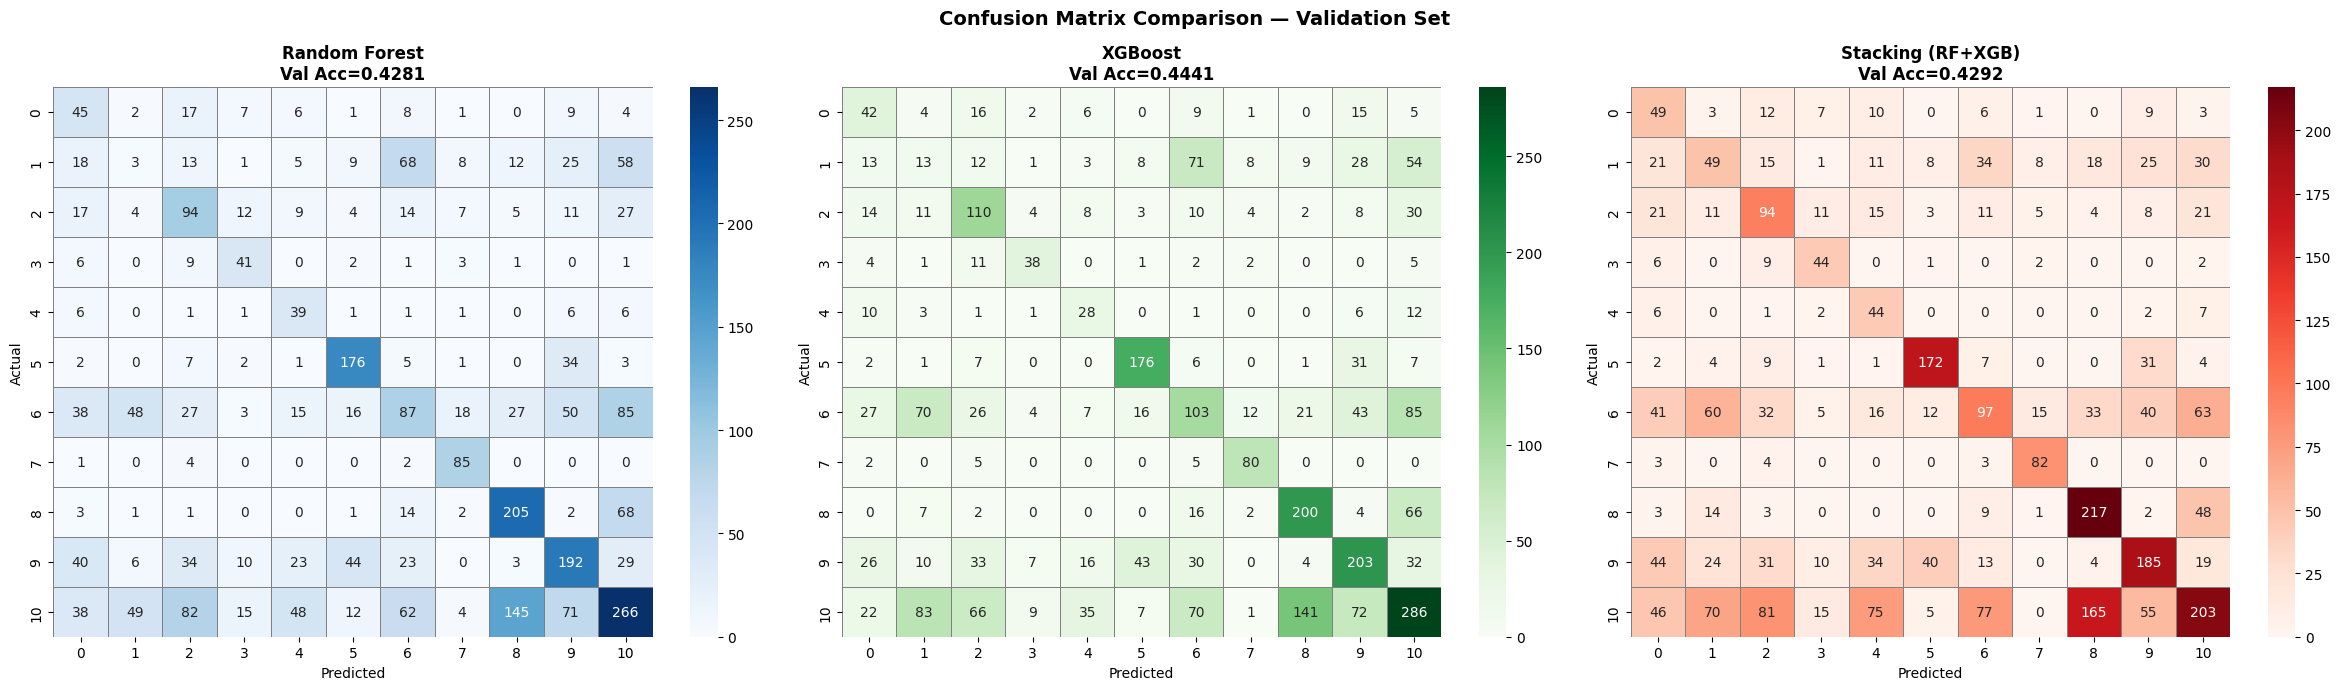

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for ax, y_pred, title, cmap in zip(
    axes,
    [y_pred_rf, y_pred_xgb, y_pred_stack],
    ['Random Forest', 'XGBoost', 'Stacking (RF+XGB)'],
    ['Blues', 'Greens', 'Reds']
):
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=classes, yticklabels=classes,
                linewidths=0.5, linecolor='gray')
    acc = accuracy_score(y_val, y_pred)
    ax.set_title(f'{title}\nVal Acc={acc:.4f}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrix Comparison — Validation Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Train Final Ensemble (gộp train + val)

Sau khi đánh giá xong trên validation, gộp toàn bộ data để train final model trước khi predict test.


In [28]:
X_full = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
y_full = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

print(f"Full dataset: {X_full.shape}")
print(f"Class distribution:\n{y_full.value_counts().sort_index()}")

sample_weights_full = compute_sample_weight(class_weight='balanced', y=y_full)

# Tìm best_iter cho XGBoost trên full data bằng cách train với early stopping trên 10% cuối
split_idx = int(len(X_full) * 0.9)
xgb_temp = XGBClassifier(
    n_estimators=1000, max_depth=8, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=0.1, min_child_weight=3,
    early_stopping_rounds=50, eval_metric='mlogloss',
    random_state=42, n_jobs=-1, verbosity=0
)
sw_temp = compute_sample_weight('balanced', y=y_full.iloc[:split_idx])
xgb_temp.fit(
    X_full.iloc[:split_idx], y_full.iloc[:split_idx],
    sample_weight=sw_temp,
    eval_set=[(X_full.iloc[split_idx:], y_full.iloc[split_idx:])],
    verbose=False
)
best_iter_full = xgb_temp.best_iteration
print(f"\nBest iteration cho full data: {best_iter_full}")

# Build final stacking với best_iter mới
rf_final = RandomForestClassifier(
    n_estimators=300, max_depth=15, min_samples_leaf=5,
    max_features='sqrt', class_weight='balanced',
    random_state=42, n_jobs=-1
)
xgb_final = XGBClassifier(
    n_estimators=best_iter_full, max_depth=8, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=0.1, min_child_weight=3,
    eval_metric='mlogloss', random_state=42, n_jobs=-1, verbosity=0
)

stack_final = StackingClassifier(
    estimators      = [('rf', rf_final), ('xgb', xgb_final)],
    final_estimator = LogisticRegression(
                          max_iter=1000, C=1.0,
                          class_weight='balanced',
                          random_state=42, n_jobs=-1
                      ),
    cv           = 5,
    stack_method = 'predict_proba',
    passthrough  = False,
    n_jobs       = -1
)

print("\nTraining final ensemble trên toàn bộ data...")
print("(mất ~5-8 phút)")
stack_final.fit(X_full, y_full)
print("Final ensemble trained!")


Full dataset: (14396, 15)
Class distribution:
Class
0      500
1     1098
2     1018
3      322
4      310
5     1157
6     2069
7      461
8     1483
9     2019
10    3959
Name: count, dtype: int64

Best iteration cho full data: 202

Training final ensemble trên toàn bộ data...
(mất ~5-8 phút)
Final ensemble trained!


## Lưu model

In [29]:
model_dir = os.path.join("..", "Model")
os.makedirs(model_dir, exist_ok=True)

joblib.dump(stack_final,             os.path.join(model_dir, "ensemble_stack_final.pkl"))
joblib.dump(X_full.columns.tolist(), os.path.join(model_dir, "feature_names_ensemble.pkl"))

print("Đã lưu ensemble_stack_final.pkl")
print("Đã lưu feature_names_ensemble.pkl")


Đã lưu ensemble_stack_final.pkl
Đã lưu feature_names_ensemble.pkl


In [11]:
macro_f1_stack   = f1_score(y_val, y_pred_stack, average='macro',    zero_division=0)
weighted_f1_stack= f1_score(y_val, y_pred_stack, average='weighted', zero_division=0)
acc_stack        = accuracy_score(y_val, y_pred_stack)

print("╔══════════════════════════════════════════════╗")
print("║    TỔNG KẾT — STACKING ENSEMBLE MODEL       ║")
print("╠══════════════════════════════════════════════╣")
print(f"║  Base model 1  : Random Forest              ║")
print(f"║  Base model 2  : XGBoost                    ║")
print(f"║  Meta-model    : Logistic Regression        ║")
print("╠══════════════════════════════════════════════╣")
print(f"║  RF   Val Accuracy  : {rf_val_acc:.4f}               ║")
print(f"║  XGB  Val Accuracy  : {xgb_val_acc:.4f}               ║")
print(f"║  Stack Val Accuracy : {acc_stack:.4f}               ║")
print(f"║  Stack Macro F1     : {macro_f1_stack:.4f}               ║")
print(f"║  Stack Weighted F1  : {weighted_f1_stack:.4f}               ║")
print("╠══════════════════════════════════════════════╣")
improvement_rf  = (acc_stack - rf_val_acc)  * 100
improvement_xgb = (acc_stack - xgb_val_acc) * 100
print(f"║  vs RF  : {improvement_rf:+.2f}%                          ║")
print(f"║  vs XGB : {improvement_xgb:+.2f}%                          ║")
print("╚══════════════════════════════════════════════╝")


╔══════════════════════════════════════════════╗
║    TỔNG KẾT — STACKING ENSEMBLE MODEL       ║
╠══════════════════════════════════════════════╣
║  Base model 1  : Random Forest              ║
║  Base model 2  : XGBoost                    ║
║  Meta-model    : Logistic Regression        ║
╠══════════════════════════════════════════════╣
║  RF   Val Accuracy  : 0.4281               ║
║  XGB  Val Accuracy  : 0.4441               ║
║  Stack Val Accuracy : 0.4292               ║
║  Stack Macro F1     : 0.4535               ║
║  Stack Weighted F1  : 0.4206               ║
╠══════════════════════════════════════════════╣
║  vs RF  : +0.10%                          ║
║  vs XGB : -1.49%                          ║
╚══════════════════════════════════════════════╝
